# Fer+ dataset

In [1]:
import pandas as pd
import numpy as np
import csv
from PIL import Image
from matplotlib import pyplot as plt
import os

## 1. Data understanding

### 1.1 data exploration & analysis

Voordat we kunnen beginnen met de dataset moeten we weten waar deze uit bestaat. Hiervoor gaan we analyses en visualisaties gebruiken. Op deze manier kunnen wij een beter inzicht krijgen van onze dataset.

Alle emoties definiëren per nummer in de dataset.

In [2]:
emotions = {0:'angry', 1:'disgust', 2:'fear', 3:'happy', 4:'sad', 5:'surprise', 6:'neutral'}

In [3]:
# De dataset lezen en alle kolomen en de eerste 5 rows laten zien.
data = pd.read_csv('ferPlus/train.csv')
relabeled_data = pd.read_csv('ferPlus/train_relabeled.csv')
data.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [4]:
# De meetwaarden,centrum en de spreidingsmaten van de dataset.
data.describe(include="all")

,emotion,pixels
count,28709.000000,28709
unique,NaN,27473
top,NaN,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
freq,NaN,11
mean,3.317427,NaN
std,1.876632,NaN
min,0.000000,NaN
25%,2.000000,NaN
50%,3.000000,NaN
75%,5.000000,NaN


Hier gaan we voor iedere emotie laten zien hoevaak die voorkomt in de dataset

In [5]:
x = data['emotion'].value_counts()[[0, 1, 2, 3, 4, 5, 6]]
for index, amount in enumerate(x):
    print(emotions[index], ': ', amount)

angry :  3995
disgust :  436
fear :  4097
happy :  7215
sad :  4830
surprise :  3171
neutral :  4965


In [6]:
# Checken hoeveel waardes we per kolom missen (dat zijn alleen de Nan waardes).
pd.isnull(data).sum()

emotion    0
pixels     0
dtype: int64

Checken of alle emoties in de dataset wel een emotie is die gedefiniëerd is.

In [7]:
count = 0

for emotion_label in data['emotion']:
    if emotion_label not in emotions:
        count += 1
        
print("Wrong labeled images: ", count)

Wrong labeled images:  0


## 2. Data preparation

### 2.1 Data cleaning

### 2.2 Data processing

Column aanmaken met een goed geformatte list van de pixels zodat je de image kan showen

In [8]:
data['formatted_pixels'] = ''

In [9]:
def format_pixels(df):
    for index, image_pixels in enumerate(df['pixels']):
        image_string = image_pixels.split(' ')
        image_data = np.asarray(image_string, dtype=np.uint8).reshape(48, 48)
        df.at[index,'formatted_pixels'] = image_data

In [10]:
format_pixels(data)

bron: https://github.com/amilkh/cs230-fer/blob/master/datasets/fer2013_csv_to_png.ipynb

In [11]:
relabeled_data.head()

,Usage,Image name,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF
0,Training,fer0000000.png,4,0,0,1,3,2,0,0,0,0
1,Training,fer0000001.png,6,0,1,1,0,0,0,0,2,0
2,Training,fer0000002.png,5,0,0,3,1,0,0,0,1,0
3,Training,fer0000003.png,4,0,0,4,1,0,0,0,1,0
4,Training,fer0000004.png,9,0,0,1,0,0,0,0,0,0


De tabellen Usage en image name hebben geen toegevoegde waarde dus mogen weg.

In [12]:
del relabeled_data['Usage']
del relabeled_data['Image name']

Pak de column name van de max van een row, zet deze in target. Dit is de meest gekozen emotie van de desbetreffende image.

In [13]:
dubble_max_rows = []
tripple_max_rows = []
quadruple_max_rows = []
five_max_rows = []
maxes = relabeled_data.max(axis=1)

for index in range(len(relabeled_data['neutral'])):
    amount_maxes = 0
    row = relabeled_data.iloc[index]    
    for x in row:
        if x == maxes[index]:
            amount_maxes += 1
    
    if amount_maxes >= 2:
        dubble_max_rows.append(index)
        
    if amount_maxes >= 3:
        tripple_max_rows.append(index)
        
    if amount_maxes >= 4:
        quadruple_max_rows.append(index)
        
    if amount_maxes >= 5:
        five_max_rows.append(index)
        
        
print('2 the same: ', len(dubble_max_rows))
print('3 the same: ', len(tripple_max_rows))
print('4 the same: ', len(quadruple_max_rows))
print('5 the same: ', len(five_max_rows))

2 the same:  1449
3 the same:  156
4 the same:  31
5 the same:  5


Dit laat zien dat we alle rows waarbij de meest gekozen emotie evenveel stemmen als een andere emotie heeft opnieuw moeten gaan labelen. Dit doen wij met een stuk code die door al deze images loopt.

In [14]:
maxValueIndexObj = relabeled_data.idxmax(axis=1)
relabeled_data['target'] = maxValueIndexObj

In [15]:
relabeled_data.head()

,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF,target
0,4,0,0,1,3,2,0,0,0,0,neutral
1,6,0,1,1,0,0,0,0,2,0,neutral
2,5,0,0,3,1,0,0,0,1,0,neutral
3,4,0,0,4,1,0,0,0,1,0,neutral
4,9,0,0,1,0,0,0,0,0,0,neutral


### make second dataframe for baseline model

In [16]:
happy_frame = pd.DataFrame(columns = ['pixels', 'happy', 'formatted_pixels'])

Vullen van de kolommen, waaronder bepalen of een image true: happy is of false: niet happy.
Dit gaan wij gebruiken voor het baseline model.

In [17]:
happy_frame['pixels'] = data['pixels']
happy_frame['happy'] = np.where(relabeled_data['target'] == 'happiness', True, False)
format_pixels(happy_frame)

happy_frame.head()

,pixels,happy,formatted_pixels
0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,False,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ..."
1,151 150 147 155 148 133 111 140 170 174 182 15...,False,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,..."
2,231 212 156 164 174 138 161 173 182 200 106 38...,False,"[[231, 212, 156, 164, 174, 138, 161, 173, 182,..."
3,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,False,"[[24, 32, 36, 30, 32, 23, 19, 20, 30, 41, 21, ..."
4,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,False,"[[4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 15, 2..."


Het Happy_frame voor ons baseline model is af dus die kan omgezet worden naar een json bestand voor het model.

In [18]:
happy_frame.to_json("ferPlus/happy_frame.json")

### Delete rows that we find unusefull

In [19]:
indexNames = relabeled_data[(relabeled_data['target'] == 'unknown') | 
                            (relabeled_data['target'] == 'contempt') | 
                            (relabeled_data['target'] == 'NF')].index

relabeled_data.drop(indexNames , inplace=True)
data.drop(indexNames , inplace=True)

Nu dat alle rows waar no face, unknown of NF wint verwijdert zijn zijn de columns ook irrelevant. Deze kunnen we dan verwijderen

In [20]:
del relabeled_data['contempt']
del relabeled_data['unknown']
del relabeled_data['NF']

In [21]:
relabeled_data.head(20)

,neutral,happiness,surprise,sadness,anger,disgust,fear,target
0,4,0,0,1,3,2,0,neutral
1,6,0,1,1,0,0,0,neutral
2,5,0,0,3,1,0,0,neutral
3,4,0,0,4,1,0,0,neutral
4,9,0,0,1,0,0,0,neutral
5,6,0,0,1,0,0,1,neutral
6,2,0,0,8,0,0,0,sadness
7,0,10,0,0,0,0,0,happiness
8,0,10,0,0,0,0,0,happiness
9,0,0,6,0,0,0,4,surprise


In [22]:
x = relabeled_data['target'].value_counts()
print(x)

neutral      10309
happiness     7528
surprise      3562
sadness       3515
anger         2467
fear           652
disgust        191
Name: target, dtype: int64


ferPlus:  neutral
fer2013 Emotion:  angry


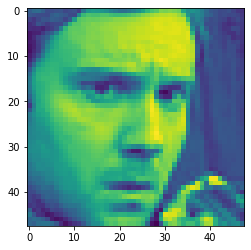

ferPlus:  neutral
fer2013 Emotion:  angry


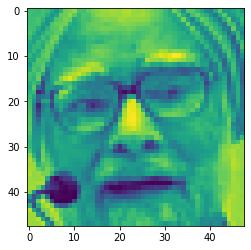

In [23]:
for picture_ind in range(0, 2):
    x = data.iloc[picture_ind]
    print('ferPlus: ', relabeled_data.iloc[picture_ind]['target'])
    print("fer2013 Emotion: ", emotions[x['emotion']])
    image = x['formatted_pixels']
    img = Image.fromarray(image)
#     img.show()
    
    imgplot = plt.imshow(img)
    plt.show()
    
plt.show()

Nu de dataframes ready to use zijn kunnen we ze terug opslaan als een json bestand. Dit doen wij zodat de modellen gelijk aan de slag kunnen met de goede data.

In [24]:
data.to_json("ferPlus/train.json")
relabeled_data.to_json("ferPlus/relabeled_data.json")